# Índice MEDI en tres niveles (estado, municipio, AGEB)

Hito **T5** de `PLAN-MEDI-ITER.md`, según ADR-0006: suma ponderada de las
siete carencias, `MEDI = Σ wᵢ · pᵢ` (escala 0–100), con intervalo
`medi_min` / `medi_max` para los componentes censurados y un componente de
**confort térmico condicional al clima** (libreta 009).

| componente | peso | estado | municipio | AGEB |
|---|---|---|---|---|
| sin electricidad | 0.24 | ITER (fila entidad) | ITER (fila municipio) | ITER |
| sin refrigerador | 0.21 | ITER | ITER | ITER |
| sin confort térmico | 0.14 | AC: ampliado; calef.: ENCEVI; necesidad: UTCI | AC: ampliado; calef.: ENCEVI (estado); necesidad: UTCI | AC: ampliado (localidad ≥ 50 k o municipio); calef.: ENCEVI (estado); necesidad: UTCI (celda) |
| combustible ≠ gas/electricidad | 0.13 | ampliado | ampliado | ampliado (localidad ≥ 50 k o municipio) |
| fogón sin chimenea | 0.13 | ampliado | ampliado | ampliado (localidad ≥ 50 k o municipio) |
| sin teléfono fijo ni celular | 0.08 | ITER | ITER | ITER |
| sin radio ni televisor | 0.07 | ITER | ITER | ITER |

Confort térmico: `p_sin_confort = p_sin_ac` donde sólo se necesita AC,
`p_sin_calef` donde sólo calefacción, la media donde ambas, 0 donde ninguna.

Depende de 005, 006, 008 y 009. **Escribe columnas nuevas dentro de**
`medi_mun_2020.parquet` y `medi_ageb_2020.parquet` (si se reejecuta 005/006
hay que volver a correr 008 → 010 → 007) y crea `medi_ent_2020.parquet`.

In [1]:
import io
import zipfile
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
RAW_INEGI = ROOT / "data" / "raw" / "INEGI"
OUT = ROOT / "data" / "derived" / "INEGI" / "2020"
MGN = RAW_INEGI / "mg_2020" / "conjunto_de_datos"
EPSG_MGN, EPSG_OUT = 6372, 4326

W = {"sin_elec": 0.24, "sin_refri": 0.21, "sin_confort": 0.14, "lena": 0.13, "fogon_sin_chim": 0.13, "sin_telef": 0.08, "sin_rtv": 0.07}
assert abs(sum(W.values()) - 1.0) < 1e-9
COL = {"sin_elec": "p_sin_elec", "sin_refri": "p_sin_refri", "sin_confort": "p_sin_confort", "lena": "p_lena",
       "fogon_sin_chim": "p_fogon_sin_chim", "sin_telef": "p_sin_telef", "sin_rtv": "p_sin_rtv"}
CENSURABLES = {"sin_elec": ("vph_s_elec", "flag_elec"), "sin_refri": ("vph_refri", "flag_refri"),
               "sin_telef": ("vph_sinltc", "flag_telef"), "sin_rtv": ("vph_sinrtv", "flag_rtv")}

amp_ent = pd.read_parquet(OUT / "ampliado_ent_2020.parquet").set_index("cve_ent")
amp_mun = pd.read_parquet(OUT / "ampliado_mun_2020.parquet").set_index("cvegeo")
amp_loc = pd.read_parquet(OUT / "ampliado_loc50k_2020.parquet").set_index("cve_loc")
clima = {lv: pd.read_parquet(OUT / f"clima_{lv}_2020.parquet") for lv in ("ageb", "mun", "ent")}
encevi = pd.read_parquet(OUT / "encevi_ent_2018.parquet").set_index("cve_ent")
umbrales = pd.read_parquet(OUT / "clima_umbrales_2020.parquet").iloc[0].to_dict()
print("umbrales climáticos:", {k: umbrales[k] for k in ("H_CALOR", "H_FRIO", "coincidencia_ac", "coincidencia_calef")})
AMP_COLS = ["p_lena", "cv_lena", "calidad_lena", "p_fogon_sin_chim", "cv_fogon_sin_chim", "calidad_fogon_sin_chim",
            "p_sin_ac", "cv_sin_ac", "calidad_sin_ac", "n_muestra"]

umbrales climáticos: {'H_CALOR': 902.0, 'H_FRIO': 626.0, 'coincidencia_ac': 0.9542033750148317, 'coincidencia_calef': 0.8777613196448675}


## 1. Funciones comunes: confort térmico, intervalo de censura, índice

In [2]:
def confort(df: pd.DataFrame) -> pd.Series:
    ac, cal = df["necesita_ac"].astype(bool), df["necesita_calef"].astype(bool)
    return pd.Series(np.select(
        [ac & cal, ac, cal],
        [(df["p_sin_ac"] + df["p_sin_calef"]) / 2.0, df["p_sin_ac"], df["p_sin_calef"]],
        0.0,
    ), index=df.index)


def indice(df: pd.DataFrame, con_censura: bool) -> pd.DataFrame:
    """medi, medi_min, medi_max (0–100) y n_censurados. Sin censura: min = max = medi."""
    out = pd.DataFrame(index=df.index)
    medi = pd.Series(0.0, index=df.index)
    lo = pd.Series(0.0, index=df.index)
    hi = pd.Series(0.0, index=df.index)
    ncens = pd.Series(0, index=df.index)
    den = df["vivparh_cv"].astype("float64") if "vivparh_cv" in df else None
    for k, w in W.items():
        p = df[COL[k]].astype("float64")
        if con_censura and k in CENSURABLES:
            flag = df[CENSURABLES[k][1]]
            cens = flag == "censurado"
            sup = np.minimum(2.0 / den * 100.0, 100.0)
            if k == "sin_elec" and "p_sin_elec_sup" in df:
                sup = df["p_sin_elec_sup"].astype("float64").where(cens, sup)
            p_lo = p.where(~cens, 0.0)
            p_hi = p.where(~cens, sup)
            p_mid = (p_lo + p_hi) / 2.0
            ncens = ncens + cens.astype(int)
        else:
            p_lo = p_hi = p_mid = p
        medi = medi + w * p_mid
        lo = lo + w * p_lo
        hi = hi + w * p_hi
    out["medi"], out["medi_min"], out["medi_max"], out["n_censurados"] = medi, lo, hi, ncens
    faltan = df[[COL[k] for k in W]].isna().any(axis=1) if not con_censura else pd.Series(False, index=df.index)
    # con censura los nulos de los censurables ya están acotados; otros nulos (sin_viviendas) dejan el índice nulo
    sin_viv = pd.Series(False, index=df.index)
    if con_censura:
        for k in CENSURABLES:
            sin_viv |= df[CENSURABLES[k][1]] == "sin_viviendas"
    out.loc[faltan | sin_viv, ["medi", "medi_min", "medi_max"]] = np.nan
    return out


def checar(out: pd.DataFrame, nombre: str):
    v = out.dropna(subset=["medi"])
    assert ((v["medi"] >= 0) & (v["medi"] <= 100)).all(), nombre
    assert (v["medi_min"] <= v["medi"] + 1e-9).all() and (v["medi"] <= v["medi_max"] + 1e-9).all(), nombre
    print(f"{nombre}: MEDI calculado en {len(v):,} de {len(out):,} unidades; media {v['medi'].mean():.2f}, máx {v['medi'].max():.2f}; "
          f"anchura media del intervalo {(v['medi_max'] - v['medi_min']).mean():.3f} pts")

## 2. Estado: los siete componentes nativos

In [3]:
ITER_ZIPS = RAW_INEGI / "iter_2020" / "ageb_manzana"
filas = []
for ee in [f"{i:02d}" for i in range(1, 33)]:
    with zipfile.ZipFile(ITER_ZIPS / f"ageb_mza_urbana_{ee}_cpv2020_csv.zip") as z:
        name = next(n for n in z.namelist() if n.split("/")[-1].startswith("conjunto_de_datos_ageb_urbana") and n.endswith(".csv"))
        raw = z.read(name)
    try:
        text = raw.decode("utf-8-sig")
    except UnicodeDecodeError:
        text = raw.decode("latin-1")
    df = pd.read_csv(io.StringIO(text), dtype=str, usecols=["ENTIDAD", "NOM_ENT", "MUN", "POBTOT", "VIVPARH_CV", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINLTC", "VPH_SINRTV"])
    filas.append(df[df["MUN"] == "000"].iloc[[0]])
est = pd.concat(filas, ignore_index=True)
est["cve_ent"] = est["ENTIDAD"].str.zfill(2)
for c in ["POBTOT", "VIVPARH_CV", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINLTC", "VPH_SINRTV"]:
    est[c] = pd.to_numeric(est[c].replace("*", pd.NA)).astype("Int64")
assert est["VIVPARH_CV"].notna().all() and len(est) == 32
est = est.set_index("cve_ent")
den = est["VIVPARH_CV"].astype("float64")
ent = pd.DataFrame({
    "nom_ent": est["NOM_ENT"], "pobtot": est["POBTOT"].astype("int64"), "vivparh_cv": est["VIVPARH_CV"].astype("int64"),
    "p_sin_elec": est["VPH_S_ELEC"] / den * 100, "p_sin_refri": (den - est["VPH_REFRI"]) / den * 100,
    "p_sin_telef": est["VPH_SINLTC"] / den * 100, "p_sin_rtv": est["VPH_SINRTV"] / den * 100,
})
ent = ent.join(amp_ent[AMP_COLS]).join(clima["ent"].set_index("cve_ent")).join(encevi[["region_encevi", "region_nombre", "p_sin_calef_ent", "p_sin_ac_encevi_ent"]])
ent["p_sin_calef"] = ent["p_sin_calef_ent"]
ent["p_sin_confort"] = confort(ent)
ent = ent.join(indice(ent, con_censura=False))
checar(ent, "estado")
print("\nAC: Censo 2020 (ampliado) vs ENCEVI 2018, % viviendas sin AC por estado (correlación):",
      round(ent[["p_sin_ac", "p_sin_ac_encevi_ent"]].corr().iloc[0, 1], 3))
rank = ent.sort_values("medi", ascending=False)[["nom_ent", "medi", "p_sin_elec", "p_sin_refri", "p_sin_confort", "p_lena", "p_fogon_sin_chim", "p_sin_telef", "p_sin_rtv"]].round(1)
print(rank.head(6).to_string()); print("..."); print(rank.tail(4).to_string())
top3 = set(rank.head(3)["nom_ent"]); assert top3 & {"Chiapas", "Oaxaca", "Guerrero"} == top3, top3
assert set(rank.tail(3)["nom_ent"]) & {"Ciudad de México", "Nuevo León", "Aguascalientes", "Baja California", "Coahuila de Zaragoza", "Colima"}

estado: MEDI calculado en 32 de 32 unidades; media 12.83, máx 36.42; anchura media del intervalo 0.000 pts

AC: Censo 2020 (ampliado) vs ENCEVI 2018, % viviendas sin AC por estado (correlación): 0.974
                                 nom_ent  medi  p_sin_elec  p_sin_refri  p_sin_confort  p_lena  p_fogon_sin_chim  p_sin_telef  p_sin_rtv
cve_ent                                                                                                                                 
07                               Chiapas  36.4         1.8         35.4           95.4    50.2              40.8         28.2       15.9
20                                Oaxaca  34.4         2.3         29.6           96.4    47.4              38.6         23.5       16.2
12                              Guerrero  30.1         1.6         19.3           92.5    42.0              37.2         18.4       13.4
30       Veracruz de Ignacio de la Llave  23.7         1.3         18.3           82.8    25.8              22.3  

## 3. Municipio

In [4]:
mun = gpd.read_parquet(OUT / "medi_mun_2020.parquet")
base_mun = [c for c in mun.columns if c not in AMP_COLS + ["necesita_ac", "necesita_calef", "h_calor", "h_frio", "p_sin_calef", "p_sin_confort",
                                                      "medi", "medi_min", "medi_max", "n_censurados", "region_encevi"]]
mun = mun[base_mun].merge(amp_mun[AMP_COLS], left_on="cvegeo", right_index=True, how="left")
mun = mun.merge(clima["mun"], on="cvegeo", how="left")
mun = mun.merge(encevi[["region_encevi", "p_sin_calef_ent"]].rename(columns={"p_sin_calef_ent": "p_sin_calef"}), left_on="cve_ent", right_index=True, how="left")
assert mun["necesita_ac"].notna().all()
sin_amp = mun.loc[mun["p_sin_ac"].isna(), "cvegeo"].tolist()
print("municipios sin datos del ampliado (cobertura 3 del Censo; MEDI nulo):", sin_amp)
assert len(sin_amp) <= 5
mun["p_sin_confort"] = confort(mun)
mun = pd.concat([mun, indice(mun, con_censura=True)], axis=1)
mun = gpd.GeoDataFrame(mun, geometry="geometry", crs=EPSG_OUT)
checar(mun, "municipio")

municipios sin datos del ampliado (cobertura 3 del Censo; MEDI nulo): ['04012', '07125', '29048']
municipio: MEDI calculado en 2,466 de 2,469 unidades; media 22.85, máx 66.64; anchura media del intervalo 0.006 pts


## 4. AGEB: hereda de la localidad ≥ 50 k si existe, si no del municipio

In [5]:
ageb = gpd.read_parquet(OUT / "medi_ageb_2020.parquet")
base_ageb = [c for c in ageb.columns if c not in AMP_COLS + ["origen_ampliado", "necesita_ac", "necesita_calef", "h_calor", "h_frio", "p_sin_calef",
                                                       "p_sin_confort", "medi", "medi_min", "medi_max", "n_censurados", "region_encevi"]]
ageb = ageb[base_ageb]
clave_loc = (ageb["cve_ent"] + ageb["cve_mun"] + ageb["cve_loc"].fillna(""))
en_loc = clave_loc.isin(amp_loc.index)          # las AGEB rurales (cve_loc nulo) van al municipio
from_loc = amp_loc.reindex(clave_loc[en_loc])[AMP_COLS].set_index(ageb.index[en_loc])
from_mun = amp_mun.reindex((ageb["cve_ent"] + ageb["cve_mun"])[~en_loc])[AMP_COLS].set_index(ageb.index[~en_loc])
ageb = ageb.join(pd.concat([from_loc, from_mun]).sort_index())
ageb["origen_ampliado"] = np.where(en_loc, "localidad", "municipio")
print(f"AGEB con ampliado de localidad ≥ 50 k: {en_loc.sum():,} ({en_loc.mean():.0%}); de municipio: {(~en_loc).sum():,}")
print("AGEB sin datos del ampliado (municipios de cobertura 3):", int(ageb["p_sin_ac"].isna().sum()))
ageb = ageb.merge(clima["ageb"], on="cvegeo", how="left")
ageb = ageb.merge(encevi[["region_encevi", "p_sin_calef_ent"]].rename(columns={"p_sin_calef_ent": "p_sin_calef"}), left_on="cve_ent", right_index=True, how="left")
assert ageb["necesita_ac"].notna().all()
ageb["p_sin_confort"] = confort(ageb)
ageb = pd.concat([ageb, indice(ageb, con_censura=True)], axis=1)
ageb = gpd.GeoDataFrame(ageb, geometry="geometry", crs=EPSG_OUT)
checar(ageb, "AGEB")

# Sensibilidad: ¿cuántas AGEB cambian de clase (6 cuantiles del MEDI) entre min y max?
v = ageb.dropna(subset=["medi"])
bins = np.quantile(v["medi"], np.linspace(0, 1, 7)[1:-1])
cambia = (np.digitize(v["medi_min"], bins) != np.digitize(v["medi_max"], bins)).mean()
print(f"AGEB cuya clase (6 cuantiles) cambia entre medi_min y medi_max: {cambia:.1%}; con algún componente censurado: {(v['n_censurados'] > 0).mean():.1%}")

AGEB con ampliado de localidad ≥ 50 k: 31,248 (39%); de municipio: 47,933
AGEB sin datos del ampliado (municipios de cobertura 3): 22
AGEB: MEDI calculado en 71,917 de 79,181 unidades; media 13.20, máx 95.24; anchura media del intervalo 0.379 pts
AGEB cuya clase (6 cuantiles) cambia entre medi_min y medi_max: 4.2%; con algún componente censurado: 38.1%


## 5. Escritura

In [6]:
ent_geo = gpd.read_file(MGN / "00ent.shp").set_crs(EPSG_MGN, allow_override=True)[["CVEGEO", "geometry"]]
ent_out = ent.reset_index().merge(ent_geo, left_on="cve_ent", right_on="CVEGEO").drop(columns="CVEGEO")
ent_out = gpd.GeoDataFrame(ent_out, geometry="geometry", crs=EPSG_MGN)
cent = ent_out.geometry.centroid.to_crs(EPSG_OUT)
ent_out["cent_lon"], ent_out["cent_lat"] = cent.x, cent.y
ent_out = ent_out.to_crs(EPSG_OUT)
ent_out.insert(0, "cvegeo", ent_out["cve_ent"])
ent_out.to_parquet(OUT / "medi_ent_2020.parquet", index=False, write_covering_bbox=True)
mun.to_parquet(OUT / "medi_mun_2020.parquet", index=False, write_covering_bbox=True)
ageb.to_parquet(OUT / "medi_ageb_2020.parquet", index=False, write_covering_bbox=True)
for n in ["medi_ent_2020", "medi_mun_2020", "medi_ageb_2020"]:
    p = OUT / f"{n}.parquet"
    chk = gpd.read_parquet(p, columns=["cvegeo", "medi", "medi_min", "medi_max", "geometry"])
    print("escrito", p.name, f"{p.stat().st_size/1e6:.1f} MB", chk.shape, "| CRS", chk.crs.to_epsg())

# La tabla puente gana los componentes heredados y el índice, para el resumen por celda
grid = pd.read_parquet(OUT / "medi_ageb_2020_grid.parquet")
grid = grid[[c for c in grid.columns if c not in ("p_lena", "p_fogon_sin_chim", "p_sin_ac", "p_sin_confort", "medi", "medi_min", "medi_max", "necesita_ac", "necesita_calef")]]
grid = grid.merge(ageb[["cvegeo", "p_lena", "p_fogon_sin_chim", "p_sin_ac", "p_sin_confort", "medi", "medi_min", "medi_max", "necesita_ac", "necesita_calef"]], on="cvegeo", how="left")
grid.to_parquet(OUT / "medi_ageb_2020_grid.parquet", index=False)
print("tabla puente actualizada:", grid.shape)

escrito medi_ent_2020.parquet 12.0 MB (32, 5) | CRS 4326
escrito medi_mun_2020.parquet 57.8 MB (2469, 5) | CRS 4326
escrito medi_ageb_2020.parquet 203.2 MB (79181, 5) | CRS 4326


tabla puente actualizada: (248503, 27)


/Users/gbv/atlas/.venv/lib/python3.13/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 6 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


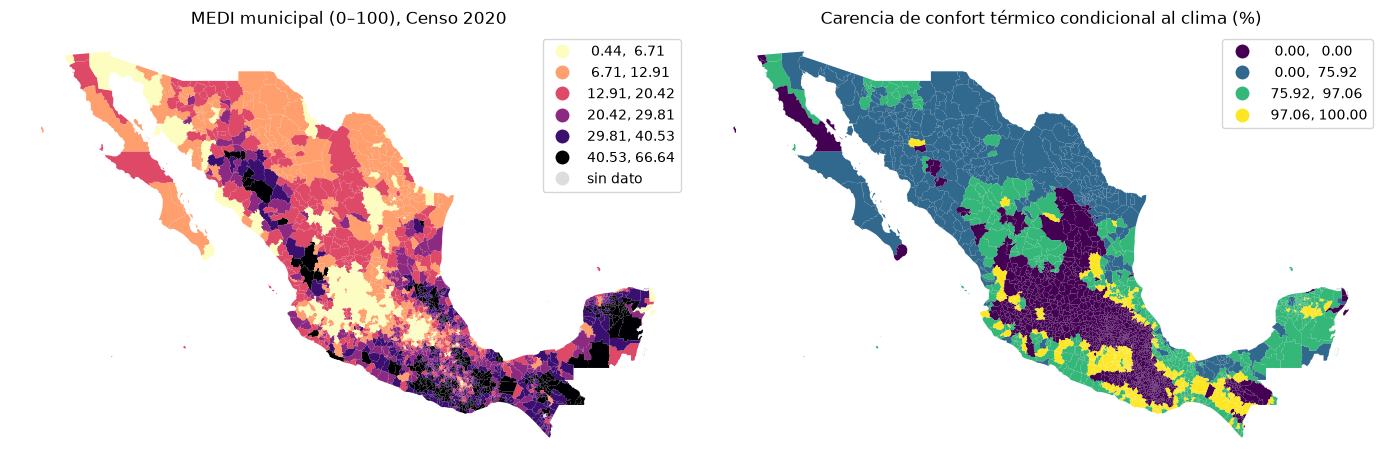

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
mun.plot(column="medi", ax=axs[0], cmap="magma_r", legend=True, scheme="quantiles", k=6, edgecolor="none",
         missing_kwds={"color": "#dddddd", "label": "sin dato"})
axs[0].set_title("MEDI municipal (0–100), Censo 2020")
mun.plot(column="p_sin_confort", ax=axs[1], cmap="viridis", legend=True, scheme="quantiles", k=6, edgecolor="none")
axs[1].set_title("Carencia de confort térmico condicional al clima (%)")
for ax in axs:
    ax.set_axis_off()
plt.tight_layout()